In [ ]:
import pandas as pd

df = pd.read_csv('world_bank_data_2025.csv')


In [ ]:
df.head(10)

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
0,Aruba,aw,2010,2.078141,2.453597e+09,24093.140151,NaN,11.666131,-1.223407,-2.733457,-18.752537,NaN,NaN,NaN,2.313385e+09,NaN
1,Aruba,aw,2011,4.316297,2.637859e+09,25712.384302,NaN,4.801974,4.005674,3.369237,-9.877656,NaN,NaN,NaN,2.391841e+09,NaN
2,Aruba,aw,2012,0.627472,2.615208e+09,25119.665545,NaN,8.200875,0.184033,-1.040800,3.473451,NaN,NaN,NaN,2.499118e+09,NaN
3,Aruba,aw,2013,-2.372065,2.727850e+09,25813.576727,NaN,10.709709,-1.995948,6.431483,-11.813206,NaN,NaN,NaN,2.563517e+09,NaN
4,Aruba,aw,2014,0.421441,2.790850e+09,26129.839062,NaN,3.213869,3.958897,-1.586575,-4.658577,NaN,NaN,NaN,2.688102e+09,NaN
5,Aruba,aw,2015,0.474764,2.962907e+09,27458.225331,NaN,0.157925,6.831287,-0.623626,3.994142,NaN,NaN,NaN,2.838144e+09,NaN
6,Aruba,aw,2016,-0.931196,2.983635e+09,27441.529662,NaN,7.982852,-1.002800,1.719625,4.731778,NaN,NaN,NaN,2.848406e+09,NaN
7,Aruba,aw,2017,-1.028282,3.092429e+09,28440.051964,NaN,9.789287,-3.178167,7.048533,1.119795,NaN,NaN,NaN,2.921801e+09,NaN
8,Aruba,aw,2018,3.626041,3.276184e+09,30082.127645,NaN,2.453045,3.462030,2.397085,-0.591367,NaN,NaN,NaN,3.061557e+09,NaN
9,Aruba,aw,2019,4.257462,3.395799e+09,31096.205074,NaN,-0.299776,6.017816,-2.232440,2.497110,NaN,NaN,NaN,3.242394e+09,NaN


In [ ]:
outlier_countries = df[df['Tax Revenue (% of GDP)'] > 50][['country_name', 'year', 'Tax Revenue (% of GDP)']]
print(outlier_countries)

print(f"Jumlah data awal: {len(df)}")

df= df[df['Tax Revenue (% of GDP)'] <= 50].copy()

print(f"Jumlah data setelah pembersihan outlier: {len(df)}")

     country_name  year  Tax Revenue (% of GDP)
3088  Timor-Leste  2010              110.172588
3089  Timor-Leste  2011              135.484451
3090  Timor-Leste  2012              147.640196
3091  Timor-Leste  2013               93.865034
3092  Timor-Leste  2014               62.790666
Jumlah data awal: 3472
Jumlah data setelah pembersihan outlier: 1828


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df = df.drop(columns=['country_name','country_id'], errors='ignore')

target_col = 'Tax Revenue (% of GDP)'
X = df.drop(columns=[target_col])
y = df[target_col]

missing_y_mask = y.isna()
X = X[~missing_y_mask]
y = y[~missing_y_mask]

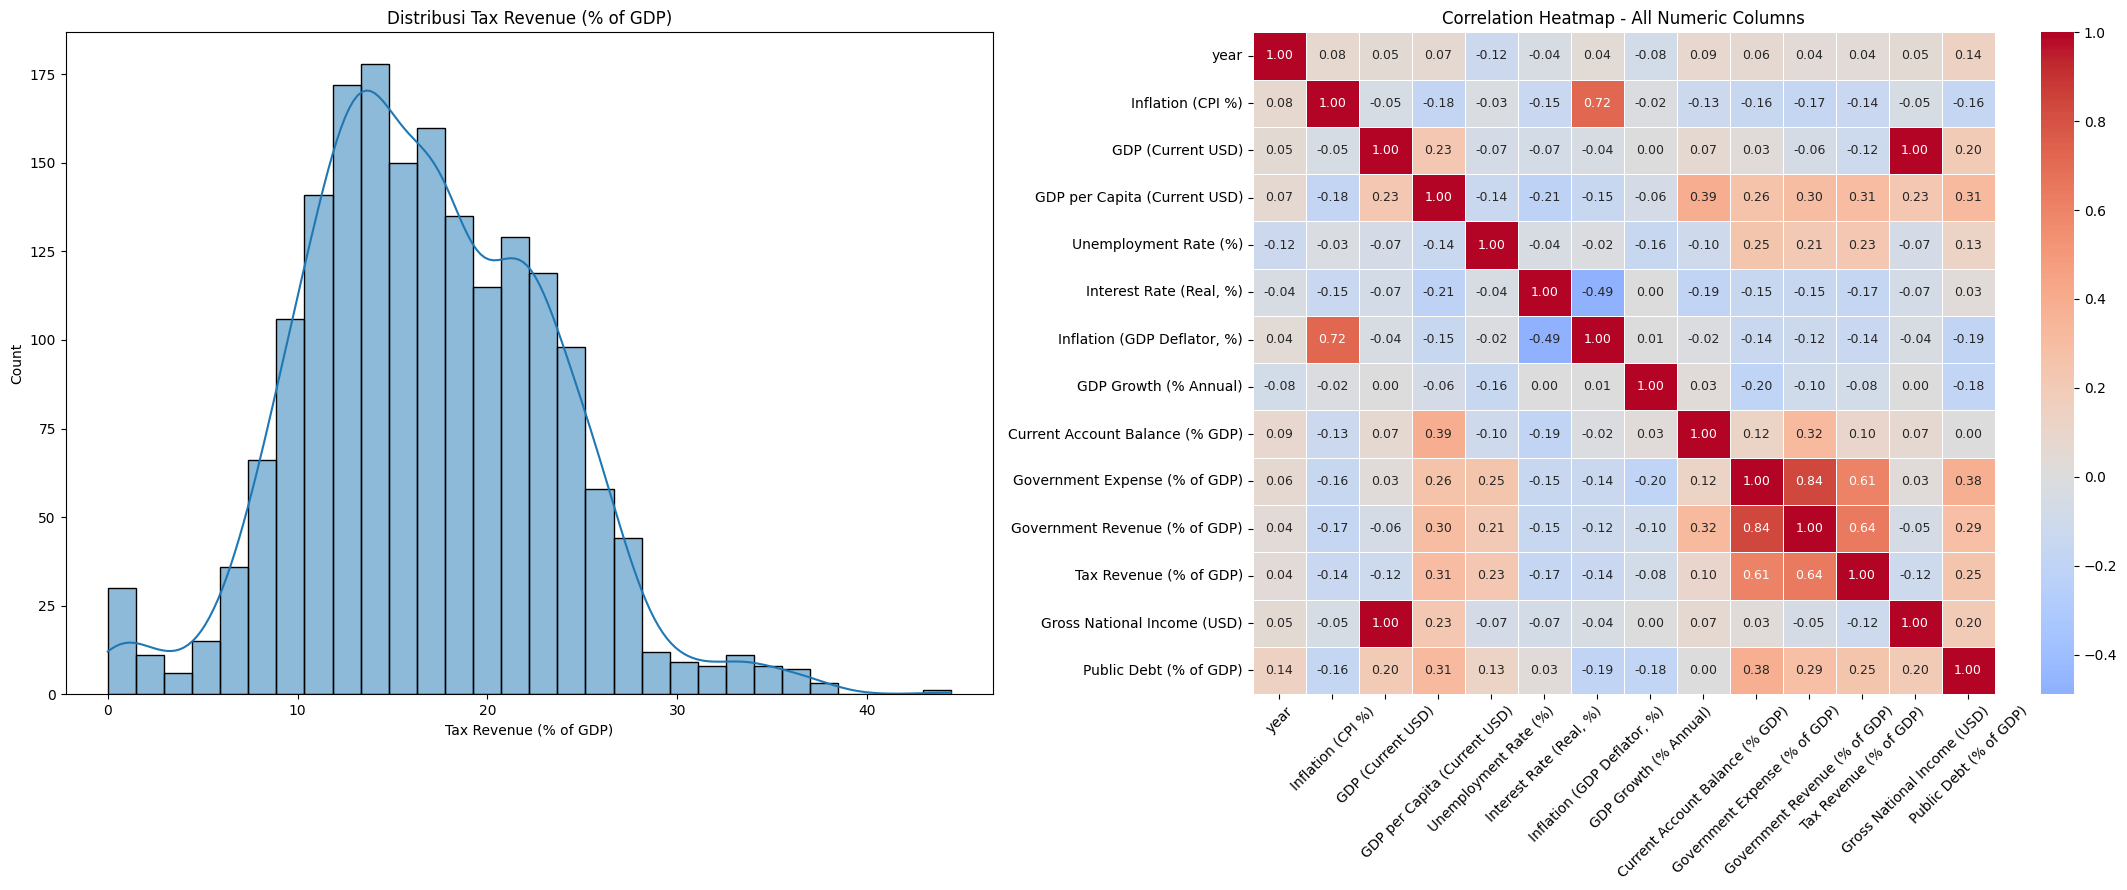

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribusi target dan heatmap seluruh kolom numerik
numeric_df = df.select_dtypes(include="number")
corr_matrix = numeric_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

sns.histplot(
    data=df,
    x=target_col,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Distribusi Tax Revenue (% of GDP)")
axes[0].set_xlabel(target_col)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 9},
    ax=axes[1]
)
axes[1].set_title("Correlation Heatmap - All Numeric Columns")
axes[1].tick_params(axis="x", labelrotation=45)
axes[1].tick_params(axis="y", labelrotation=0)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
import numpy as np

numeric_cols = X_train.select_dtypes(include=[np.number]).columns

mice_imputer = IterativeImputer(max_iter=10, random_state=42)
X_train_imputed = mice_imputer.fit_transform(X_train[numeric_cols])
X_test_imputed = mice_imputer.transform(X_test[numeric_cols])

X_train_clean = pd.DataFrame(
    X_train_imputed, columns=numeric_cols, index=X_train.index
)
X_test_clean = pd.DataFrame(
    X_test_imputed, columns=numeric_cols, index=X_test.index
)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_clean, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test_clean)
residuals = y_test - y_pred

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== METRIK EVALUASI MODEL ===")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

=== METRIK EVALUASI MODEL ===
MAE  : 1.5577
MSE  : 6.0750
RMSE : 2.4647
R²   : 0.8558


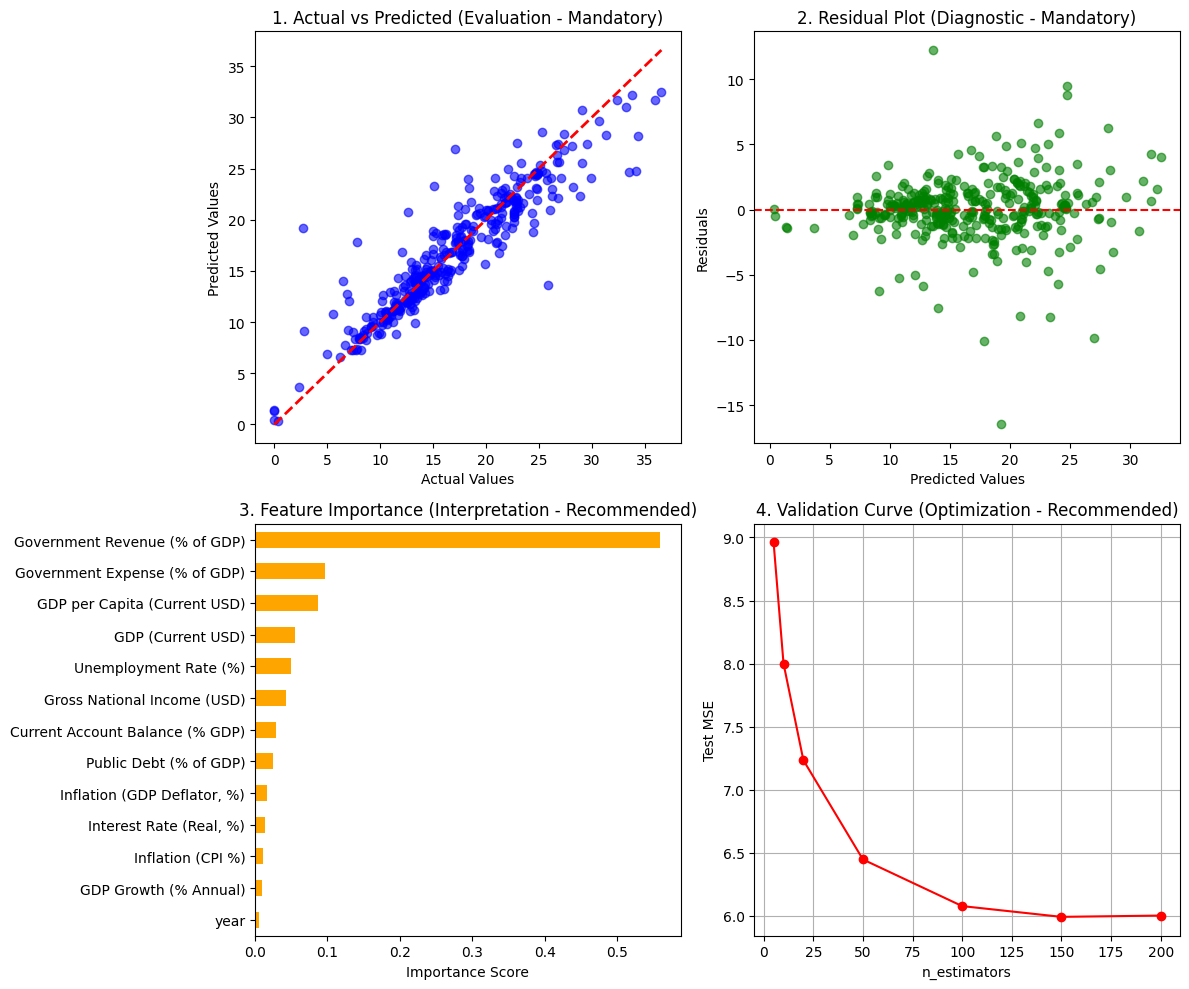

In [ ]:

fig_eval, axes_eval = plt.subplots(2, 2, figsize=(12, 10))

axes_eval[0, 0].scatter(y_test, y_pred, alpha=0.6, color='blue')
axes_eval[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes_eval[0, 0].set_title('1. Actual vs Predicted (Evaluation - Mandatory)')
axes_eval[0, 0].set_xlabel('Actual Values')
axes_eval[0, 0].set_ylabel('Predicted Values')

axes_eval[0, 1].scatter(y_pred, residuals, alpha=0.6, color='green')
axes_eval[0, 1].axhline(0, color='red', linestyle='--')
axes_eval[0, 1].set_title('2. Residual Plot (Diagnostic - Mandatory)')
axes_eval[0, 1].set_xlabel('Predicted Values')
axes_eval[0, 1].set_ylabel('Residuals')

importances = pd.Series(model.feature_importances_, index=X_train_clean.columns).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes_eval[1, 0], color='orange')
axes_eval[1, 0].set_title('3. Feature Importance (Interpretation - Recommended)')
axes_eval[1, 0].set_xlabel('Importance Score')

n_estimators_list = [5, 10, 20, 50, 100, 150, 200]
test_mses = []
for n in n_estimators_list:
    rf = RandomForestRegressor(n_estimators=n, random_state=42)
    rf.fit(X_train_clean, y_train)
    test_mses.append(mean_squared_error(y_test, rf.predict(X_test_clean)))

axes_eval[1, 1].plot(n_estimators_list, test_mses, marker='o', color='red')
axes_eval[1, 1].set_title('4. Validation Curve (Optimization - Recommended)')
axes_eval[1, 1].set_xlabel('n_estimators')
axes_eval[1, 1].set_ylabel('Test MSE')
axes_eval[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
df_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Error (Residual)': y_test.values - y_pred,
    'Absolute Error': abs(y_test.values - y_pred)
}, index=y_test.index)

df_results.insert(0, 'year', df.loc[df_results.index, 'year'])

df_results.head(10)

,year,Actual,Predicted,Error (Residual),Absolute Error
428,2022,14.725848,14.609854,0.115994,0.115994
2358,2016,25.312726,28.595342,-3.282616,3.282616
2884,2014,17.388467,20.505155,-3.116688,3.116688
2013,2023,14.266598,12.874054,1.392544,1.392544
2115,2013,15.731208,17.934918,-2.203710,2.203710
636,2022,11.411023,11.547194,-0.136171,0.136171
2192,2010,10.563465,10.437778,0.125687,0.125687
1496,2018,22.978361,27.513627,-4.535265,4.535265
1111,2017,23.013546,20.851595,2.161951,2.161951
488,2018,21.740495,22.118027,-0.377533,0.377533


In [ ]:
data_future = pd.DataFrame({
    'year': [2026, 2027],
    'Government Revenue (% of GDP)': [15.2, 15.5],
    'Current Account Balance (% GDP)': [-1.1, -1.0],
    'Unemployment Rate (%)': [4.8, 4.6],
    'Interest Rate (Real, %)': [2.5, 2.3],
    'GDP Growth (% Annual)': [5.1, 5.3],
    'Government Expense (% of GDP)': [17.0, 17.1],
    'Public Debt (% of GDP)': [39.5, 39.0],
    'Inflation (CPI %)': [2.8, 2.5],
    'GDP (Current USD)': [1.5e12, 1.6e12],
    'GDP per Capita (Current USD)': [5300, 5600]
})

kolom_hilang = [
    col for col in X_train_clean.columns
    if col not in data_future.columns
]

for col in kolom_hilang:
    data_future[col] = X_train_clean[col].median()

X_future = data_future.reindex(columns=X_train_clean.columns)

data_future['Predicted_Tax_Revenue'] = model.predict(X_future)

print(data_future[['year', 'Predicted_Tax_Revenue']])

   year  Predicted_Tax_Revenue
0  2026              11.183513
1  2027              11.119348
